Starting Extra Trees Classifier SHAP Analysis...
Loading data from your specified path...
Data loaded successfully!
Dataset shape: (16000, 82)

Dataset Information:
Shape: (16000, 82)

Column names:
 1. Personal_Code
 2. Days_Visited_Two_Hospitals
 3. Months_Visited
 4. Max_Monthly_Visit_Days
 5. Avg_Monthly_Visit_Days
 6. Max_Monthly_Hospitals_Visited
 7. Avg_Monthly_Hospitals_Visited
 8. Total_Visits
 9. Max_Monthly_Visits
10. Avg_Monthly_Visits
11. Max_Monthly_Pooled_Amount
12. Avg_Monthly_Pooled_Amount
13. Max_Monthly_Drug_Cost
14. Avg_Monthly_Drug_Cost
15. Max_Hospital_Visit_Days
16. Avg_Hospital_Visit_Days
17. Max_Hospital_Pooled_Amount
18. Avg_Hospital_Pooled_Amount
19. Max_Hospital_Drug_Cost
20. Avg_Hospital_Drug_Cost
21. Hospital_Code
22. Sequence_Number
23. Transaction_Day
24. Transaction_Year
25. Transaction_YearMonth
26. Total_Hospitalization_Days
27. Total_Personal_Account_Amount
28. Total_Pooled_Payment
29. Total_All_Expenses
30. Total_Reimbursable_Account_Amount
31. Tota

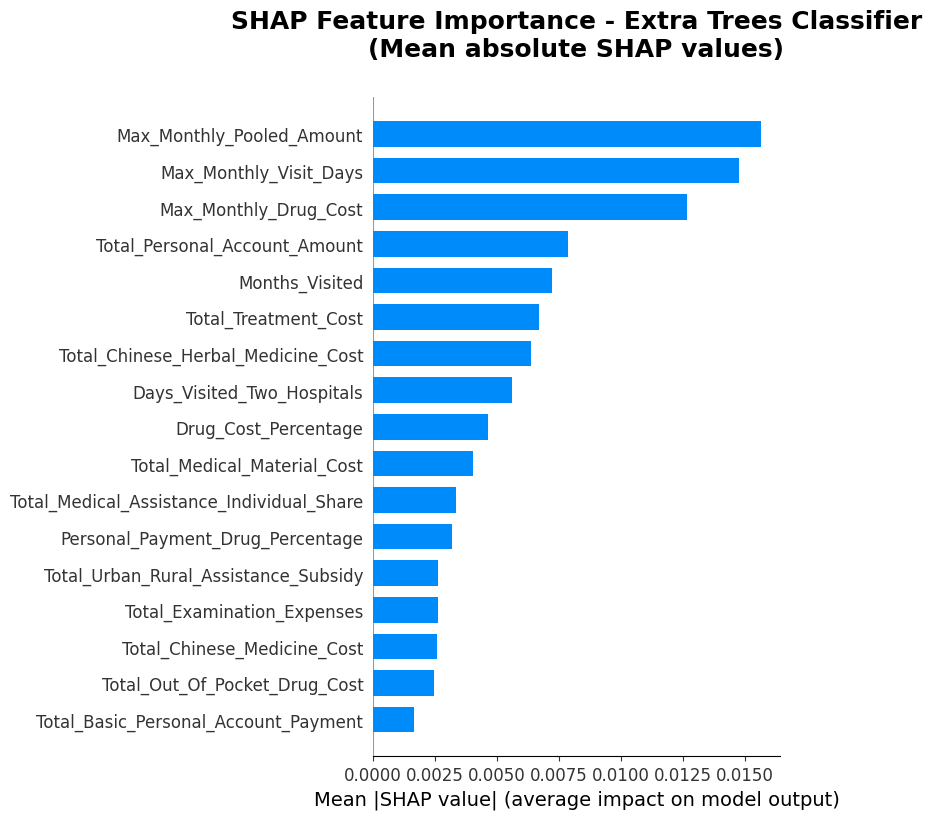

Creating detailed SHAP Summary plot...


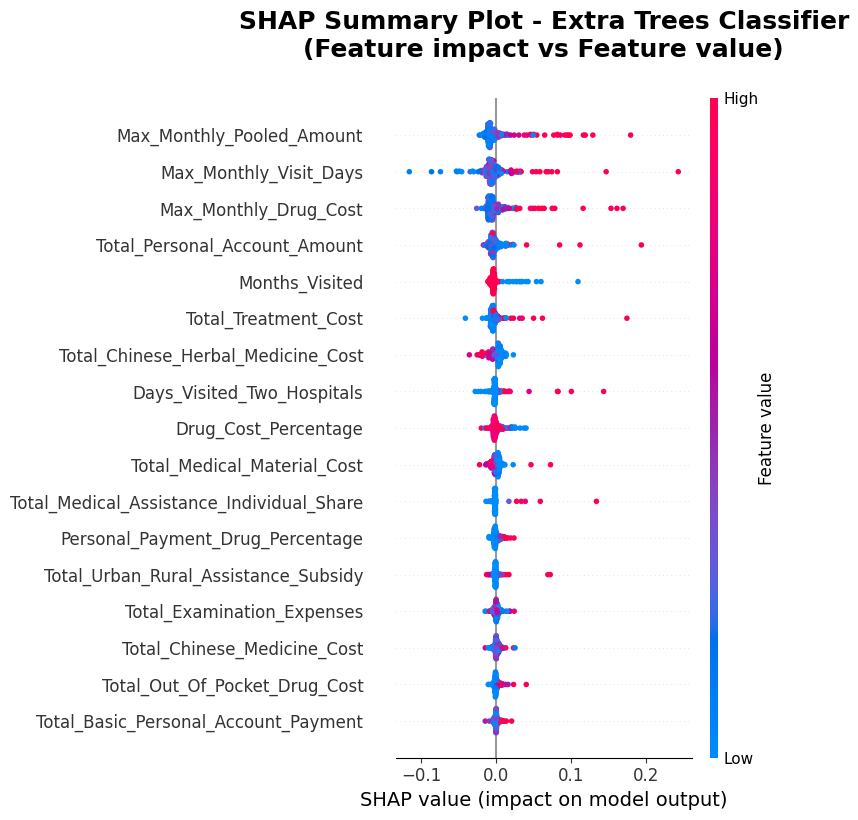

Calculating feature importance comparison...

Top 15 Most Important Features (SHAP-based):
                                      Feature  Extra_Trees_Importance  \
0                   Max_Monthly_Pooled_Amount                0.121015   
3                      Max_Monthly_Visit_Days                0.117259   
1                       Max_Monthly_Drug_Cost                0.113327   
2               Total_Personal_Account_Amount                0.093352   
16                             Months_Visited                0.045796   
4                        Total_Treatment_Cost                0.066523   
12         Total_Chinese_Herbal_Medicine_Cost                0.032654   
14                 Days_Visited_Two_Hospitals                0.057659   
5                        Drug_Cost_Percentage                0.048108   
10                Total_Medical_Material_Cost                0.035659   
13  Total_Medical_Assistance_Individual_Share                0.040127   
9            Personal_Payment_Dru

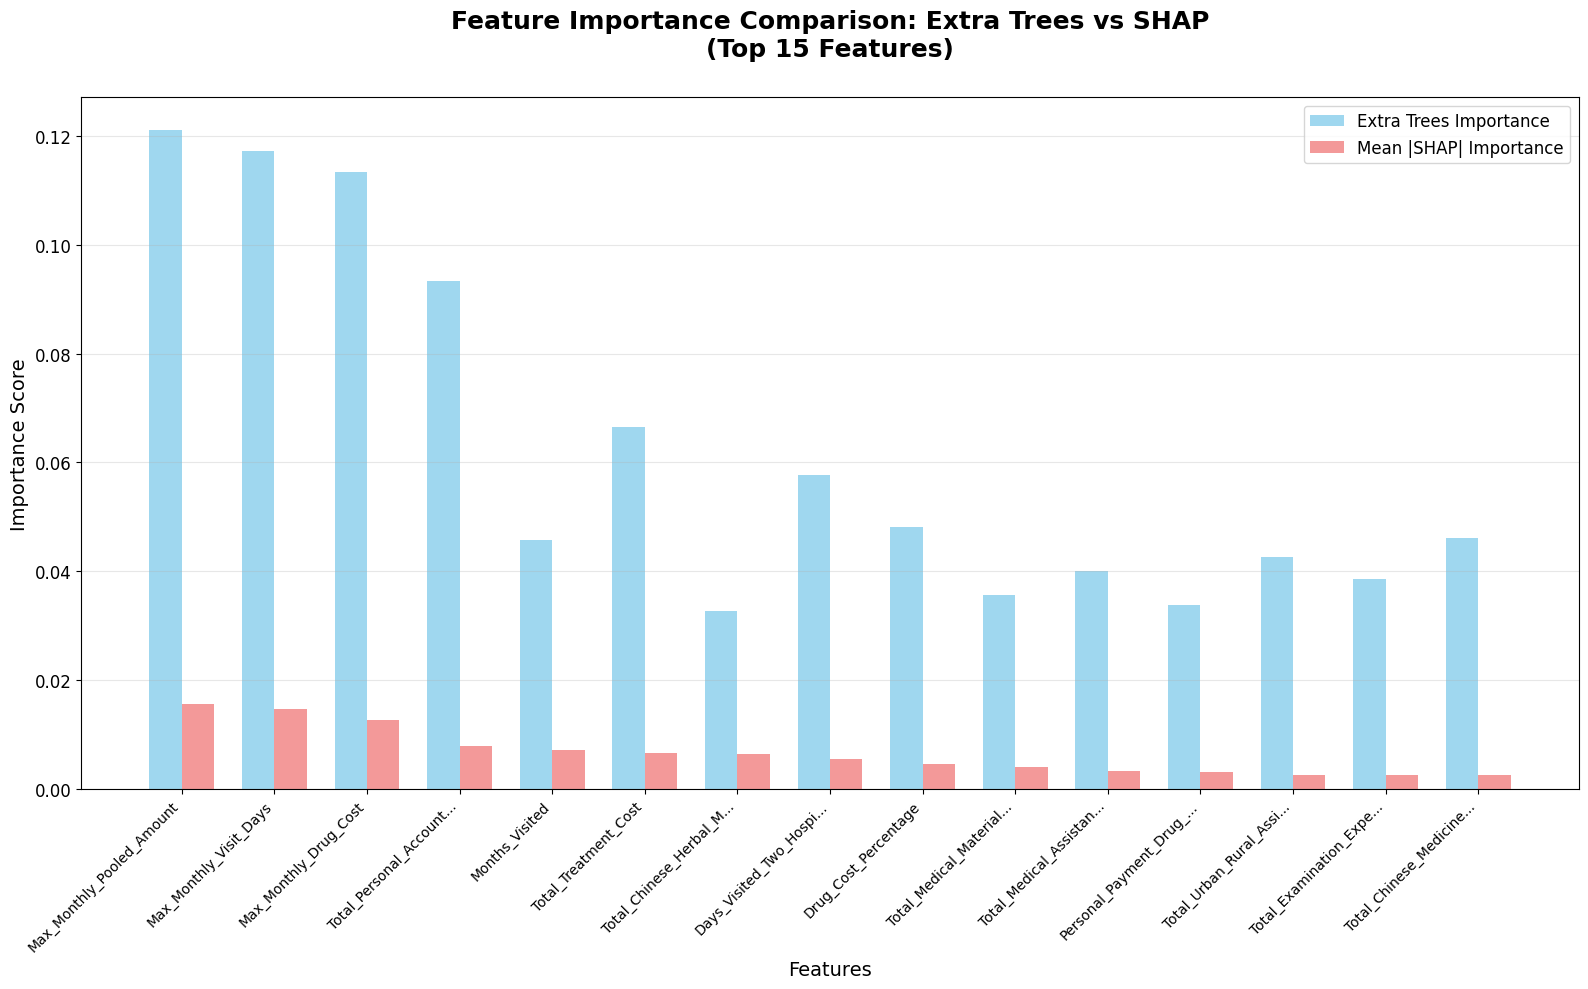

Creating individual prediction explanations...


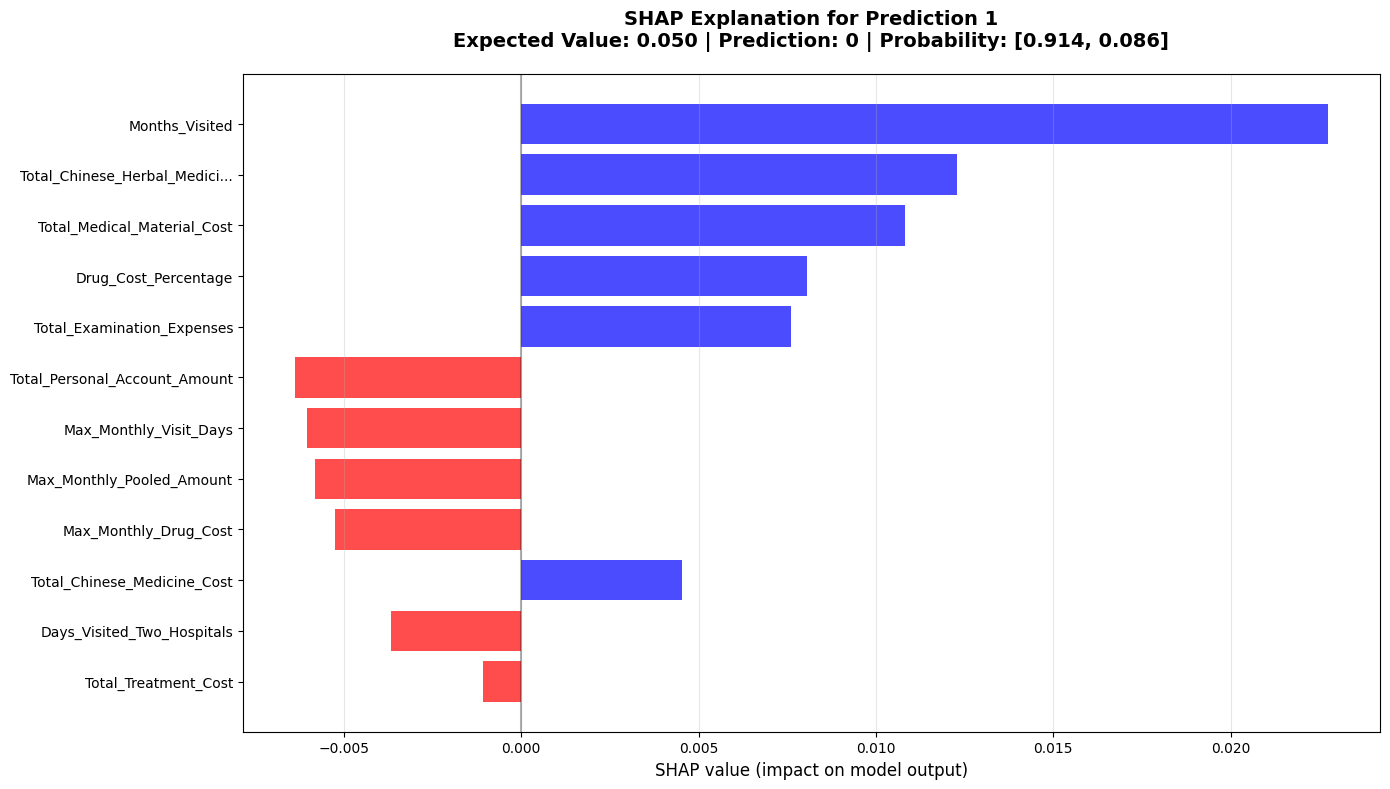

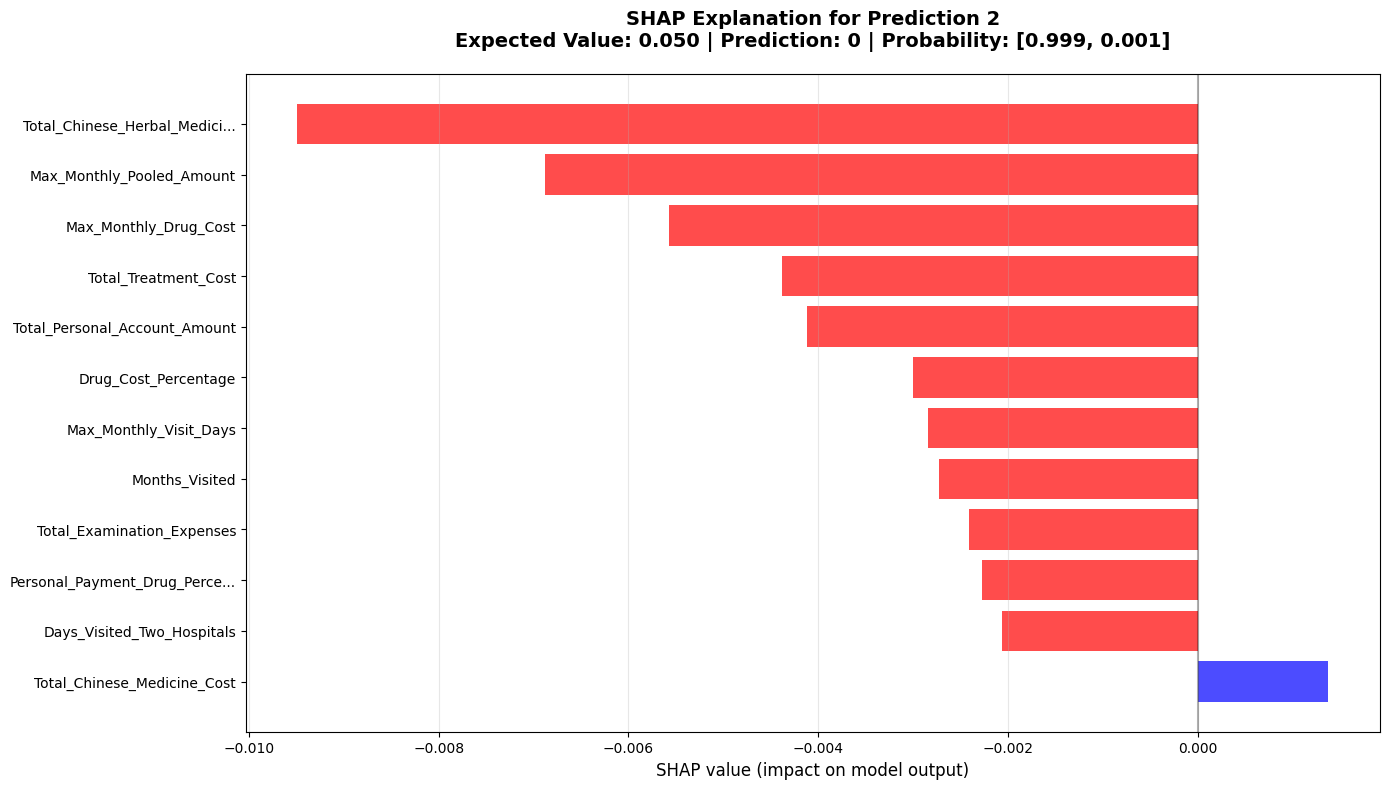

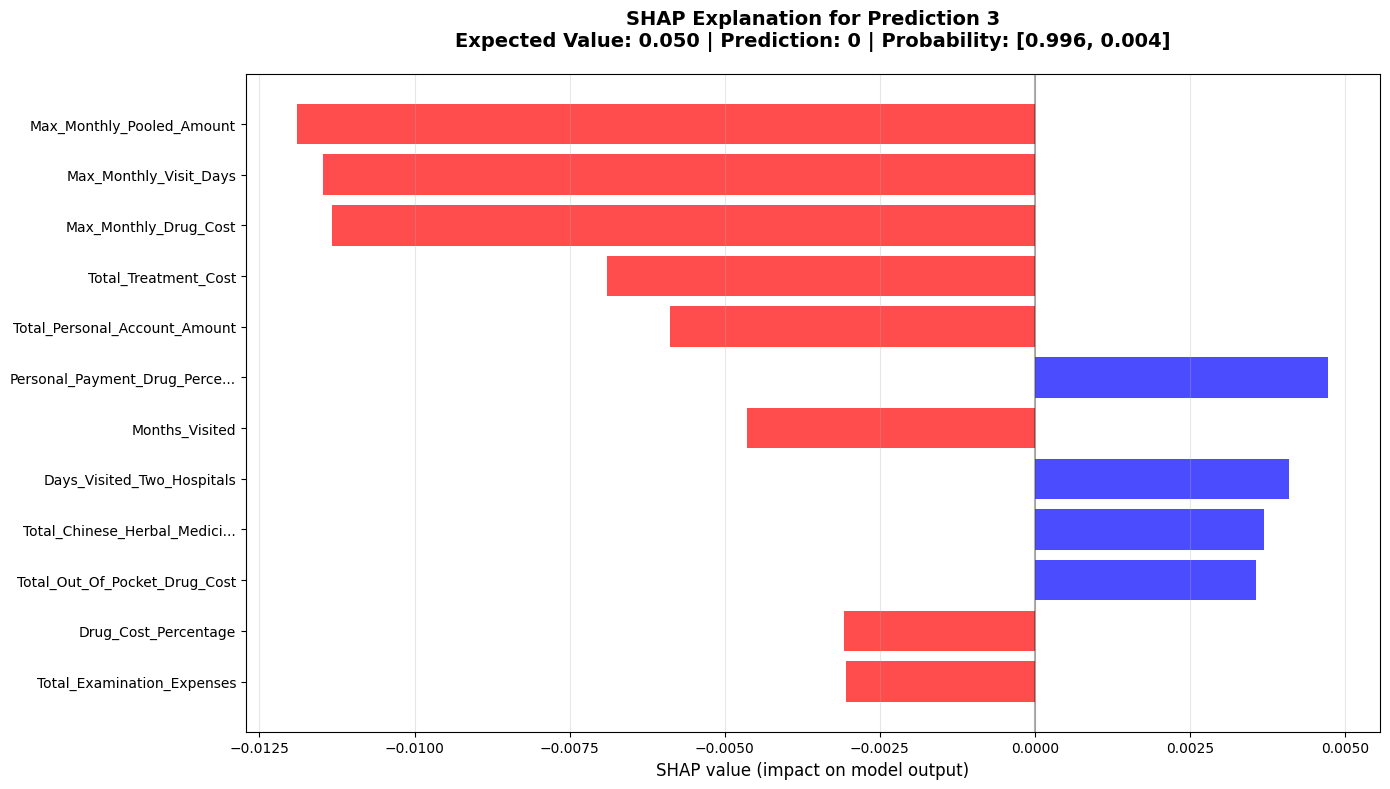


SHAP ANALYSIS COMPLETE!

Key Results Summary:
• Dataset: 16,000 samples, 17 features
• Model Accuracy: 0.9616 (96.2%)
• Target Distribution: {0: np.int64(15207), 1: np.int64(793)}

Top 5 Most Important Features (by Mean |SHAP| value):
  1. Max_Monthly_Pooled_Amount
     SHAP Importance: 0.015627
     Extra Trees Importance: 0.121015

  2. Max_Monthly_Visit_Days
     SHAP Importance: 0.014750
     Extra Trees Importance: 0.117259

  3. Max_Monthly_Drug_Cost
     SHAP Importance: 0.012642
     Extra Trees Importance: 0.113327

  4. Total_Personal_Account_Amount
     SHAP Importance: 0.007878
     Extra Trees Importance: 0.093352

  5. Months_Visited
     SHAP Importance: 0.007215
     Extra Trees Importance: 0.045796

Interpretation Guide:
• Red bars (negative SHAP): Decrease prediction probability
• Blue bars (positive SHAP): Increase prediction probability
• Larger absolute values = stronger impact on predictions
• SHAP values explain individual predictions, not just overall importanc

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import shap
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

print("Starting Extra Trees Classifier SHAP Analysis...")
print("="*60)

# Load the data with your specific path and separator
print("Loading data from your specified path...")
df = pd.read_csv(r"C:\Users\Given\Downloads\Health Insurance Cleaned.csv", sep=";")

print("Data loaded successfully!")
print(f"Dataset shape: {df.shape}")

# Display basic information about the dataset
print(f"\nDataset Information:")
print(f"Shape: {df.shape}")
print(f"\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

print(f"\nFirst few rows:")
print(df.head())

print(f"\nData types:")
print(df.dtypes)

# Define the features as specified
feature_columns = [
    'Max_Monthly_Pooled_Amount',
    'Max_Monthly_Drug_Cost', 
    'Total_Personal_Account_Amount',
    'Max_Monthly_Visit_Days',
    'Total_Treatment_Cost',
    'Drug_Cost_Percentage',
    'Total_Chinese_Medicine_Cost',
    'Total_Out_Of_Pocket_Drug_Cost',
    'Total_Examination_Expenses',
    'Personal_Payment_Drug_Percentage',
    'Max_Discharge_Material_Cost',
    'Total_Medical_Material_Cost',
    'Total_Diagnosis_Length',
    'Discharge_Expensive_Drug_Cost',
    'Total_Basic_Personal_Account_Payment',
    'Total_Chinese_Herbal_Medicine_Cost',
    'Total_Medical_Assistance_Individual_Share',
    'Days_Visited_Two_Hospitals',
    'Total_Urban_Rural_Assistance_Subsidy',
    'Months_Visited'
]

target_column = 'Result'

# Check for missing columns
missing_features = [col for col in feature_columns if col not in df.columns]
if missing_features:
    print(f"\nWarning: Missing feature columns: {missing_features}")
    # Remove missing columns from the list
    available_features = [col for col in feature_columns if col in df.columns]
    print(f"Available features: {len(available_features)}")
    feature_columns = available_features
else:
    print(f"\nAll {len(feature_columns)} specified features found in dataset!")

if target_column not in df.columns:
    print(f"\nError: Target column '{target_column}' not found!")
    print("Available columns:", df.columns.tolist())
    exit()
else:
    print(f"Target column '{target_column}' found successfully")

# Display target distribution
print(f"\nTarget variable distribution:")
target_counts = df[target_column].value_counts()
print(target_counts)
print(f"Target percentage:")
print(df[target_column].value_counts(normalize=True).round(4))

# Prepare the data
print(f"\nPreparing data for modeling...")
X = df[feature_columns].copy()
y = df[target_column].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Check for missing values
print(f"\nChecking for missing values...")
missing_counts = X.isnull().sum()
if missing_counts.sum() > 0:
    print("Missing values per feature:")
    print(missing_counts[missing_counts > 0])
    print("\nFilling missing values with median...")
    X = X.fillna(X.median())
else:
    print("No missing values found in features")

# Remove rows with missing target values
if y.isnull().sum() > 0:
    print(f"Found {y.isnull().sum()} missing values in target")
    mask = ~y.isnull()
    X = X[mask]
    y = y[mask]
    print(f"Removed rows with missing target values")

print(f"Final dataset shape: {X.shape}")

# Display basic statistics
print(f"\nBasic statistics for features:")
print(X.describe().round(2))

# Split the data
print(f"\nSplitting data (80% train, 20% test)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training target distribution:")
print(y_train.value_counts(normalize=True).round(4))

# Train Extra Trees Classifier
print(f"\nTraining Extra Trees Classifier...")
model = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model training completed!")

# Evaluate model
print(f"\nEvaluating model performance...")
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Performance:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# Initialize SHAP explainer
print(f"\nInitializing SHAP TreeExplainer...")
explainer = shap.TreeExplainer(model)

# Use a reasonable sample size for SHAP calculation
sample_size = min(200, len(X_test))
X_sample = X_test.iloc[:sample_size]
print(f"Calculating SHAP values for {sample_size} samples...")

shap_values = explainer.shap_values(X_sample)

# Handle different SHAP value formats
if isinstance(shap_values, list):
    if len(shap_values) == 2:
        print("Binary classification detected - using positive class SHAP values")
        shap_values = shap_values[1]
    else:
        print(f"Multi-class classification detected with {len(shap_values)} classes")
        shap_values = shap_values[-1]  # Use last class
elif len(shap_values.shape) == 3:
    print("3D SHAP array detected - using positive class")
    shap_values = shap_values[:, :, 1]

print(f"SHAP values shape: {shap_values.shape}")

# Generate SHAP visualizations
print(f"\nGenerating SHAP visualizations...")
print("="*60)

# 1. SHAP Feature Importance (Bar Plot)
print("Creating SHAP Feature Importance plot...")
plt.figure(figsize=(14, 10))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, max_display=20)
plt.title('SHAP Feature Importance - Extra Trees Classifier\n(Mean absolute SHAP values)', 
          fontsize=18, fontweight='bold', pad=30)
plt.xlabel('Mean |SHAP value| (average impact on model output)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# 2. SHAP Summary Plot with feature values
print("Creating detailed SHAP Summary plot...")
plt.figure(figsize=(14, 12))
shap.summary_plot(shap_values, X_sample, show=False, max_display=20)
plt.title('SHAP Summary Plot - Extra Trees Classifier\n(Feature impact vs Feature value)', 
          fontsize=18, fontweight='bold', pad=30)
plt.xlabel('SHAP value (impact on model output)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# 3. Feature importance comparison
print("Calculating feature importance comparison...")
mean_abs_shap = np.abs(shap_values).mean(0)

feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Extra_Trees_Importance': model.feature_importances_,
    'Mean_SHAP_Importance': mean_abs_shap
}).sort_values('Mean_SHAP_Importance', ascending=False)

print(f"\nTop 15 Most Important Features (SHAP-based):")
print("="*80)
print(feature_importance.head(15).round(6))

# 4. Comparison plot
print("Creating importance comparison plot...")
plt.figure(figsize=(16, 10))
top_features = feature_importance.head(15)

x = np.arange(len(top_features))
width = 0.35

bars1 = plt.bar(x - width/2, top_features['Extra_Trees_Importance'], 
               width, label='Extra Trees Importance', alpha=0.8, color='skyblue')
bars2 = plt.bar(x + width/2, top_features['Mean_SHAP_Importance'], 
               width, label='Mean |SHAP| Importance', alpha=0.8, color='lightcoral')

plt.xlabel('Features', fontsize=14)
plt.ylabel('Importance Score', fontsize=14)
plt.title('Feature Importance Comparison: Extra Trees vs SHAP\n(Top 15 Features)', 
          fontsize=18, fontweight='bold', pad=30)

# Truncate long feature names for better display
feature_labels = []
for feat in top_features['Feature']:
    if len(feat) > 25:
        feature_labels.append(feat[:22] + '...')
    else:
        feature_labels.append(feat)

plt.xticks(x, feature_labels, rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Individual prediction explanations
print("Creating individual prediction explanations...")
for i in range(min(3, len(X_sample))):
    plt.figure(figsize=(14, 8))
    
    expected_value = explainer.expected_value
    if isinstance(expected_value, np.ndarray):
        expected_value = expected_value[1] if len(expected_value) > 1 else expected_value[0]
    elif isinstance(expected_value, list):
        expected_value = expected_value[1] if len(expected_value) > 1 else expected_value[0]
    
    # Get SHAP values for this prediction and sort by absolute value
    sample_shap = shap_values[i]
    feature_shap_pairs = list(zip(feature_columns, sample_shap))
    feature_shap_pairs.sort(key=lambda x: abs(x[1]), reverse=True)
    
    # Take top 12 features for display
    top_features_individual = feature_shap_pairs[:12]
    features, values = zip(*top_features_individual)
    
    colors = ['red' if v < 0 else 'blue' for v in values]
    
    y_pos = np.arange(len(features))
    bars = plt.barh(y_pos, values, color=colors, alpha=0.7)
    
    # Truncate feature names for display
    display_features = []
    for f in features:
        if len(f) > 30:
            display_features.append(f[:27] + '...')
        else:
            display_features.append(f)
    
    plt.yticks(y_pos, display_features, fontsize=10)
    plt.xlabel('SHAP value (impact on model output)', fontsize=12)
    
    actual_prediction = model.predict(X_sample.iloc[[i]])[0]
    prediction_proba = model.predict_proba(X_sample.iloc[[i]])[0]
    
    plt.title(f'SHAP Explanation for Prediction {i+1}\n'
             f'Expected Value: {expected_value:.3f} | '
             f'Prediction: {actual_prediction} | '
             f'Probability: [{prediction_proba[0]:.3f}, {prediction_proba[1]:.3f}]', 
             fontsize=14, fontweight='bold', pad=20)
    
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(axis='x', alpha=0.3)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# 6. Final summary
print(f"\n" + "="*80)
print(f"SHAP ANALYSIS COMPLETE!")
print(f"="*80)

print(f"\nKey Results Summary:")
print(f"• Dataset: {df.shape[0]:,} samples, {len(feature_columns)} features")
print(f"• Model Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"• Target Distribution: {dict(y.value_counts())}")

print(f"\nTop 5 Most Important Features (by Mean |SHAP| value):")
for i, (_, row) in enumerate(feature_importance.head(5).iterrows(), 1):
    print(f"  {i}. {row['Feature']}")
    print(f"     SHAP Importance: {row['Mean_SHAP_Importance']:.6f}")
    print(f"     Extra Trees Importance: {row['Extra_Trees_Importance']:.6f}")
    print()

print(f"Interpretation Guide:")
print(f"• Red bars (negative SHAP): Decrease prediction probability")
print(f"• Blue bars (positive SHAP): Increase prediction probability") 
print(f"• Larger absolute values = stronger impact on predictions")
print(f"• SHAP values explain individual predictions, not just overall importance")

print(f"\nAll visualizations have been generated successfully!")
print(f"The plots show feature importance rankings and individual prediction explanations.")